# Week08 Lab — Data Integration Pipeline
## TechTrove E-Commerce: จากข้อมูลดิบหลายระบบสู่ข้อมูลพร้อมวิเคราะห์

Notebook นี้เดินตามหัวข้อ 5.1–5.6 ในใบงาน โดยเรียกใช้ฟังก์ชันจาก `integration_pipeline.py`
เพื่อให้โค้ดมีแหล่งความจริงเดียว (ไฟล์ `.py` กับ notebook ให้ผลลัพธ์ตรงกันเสมอ)

| แหล่งข้อมูล | ไฟล์ | ระบบต้นทาง |
|---|---|---|
| คำสั่งซื้อ ม.ค. | `orders_2026_01.csv` | Transaction |
| คำสั่งซื้อ ก.พ. | `orders_2026_02.csv` | Transaction (schema ต่างจาก ม.ค.) |
| ลูกค้า | `customers_crm.csv` | CRM |
| สินค้า | `product_master.xlsx` | ฝ่ายจัดซื้อ |
| การชำระเงิน | `payments.json` | Payment Gateway (nested) |

**กติกาทางธุรกิจ** — หนึ่ง `order_id` ต่อหนึ่งแถว (ซ้ำให้เก็บล่าสุด), `quantity > 0`,
`unit_price > 0`, `0 ≤ discount ≤ 1`, ลูกค้าและสินค้าต้องพบใน Master Data,
นับเป็นยอดขายเมื่อ `payment.status == "PAID"` และ
`net_sales = quantity × unit_price × (1 - discount)`

In [1]:
import json
from pathlib import Path

import pandas as pd

import integration_pipeline as ip

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print("data:", ip.DATA)
print("ไฟล์ต้นทาง:", sorted(p.name for p in ip.DATA.glob("*") if p.name != ".gitkeep"))

data: D:\work\data_warehouse\06_data_integration\data
ไฟล์ต้นทาง: ['customers_crm.csv', 'orders_2026_01.csv', 'orders_2026_02.csv', 'payments.json', 'product_master.xlsx']


---
## 5.1 Extract & Profile — คุณภาพข้อมูล **ก่อน** ทำ Data Integration

อ่านครบทั้ง CSV, Excel และ nested JSON แล้วสำรวจ shape / dtype / missing / duplicate / ตัวอย่างค่า
โดยยังไม่แก้ไขอะไรทั้งสิ้น เพื่อเก็บเป็นหลักฐานสภาพเริ่มต้น

In [2]:
raw = ip.extract(verbose=False)

profiles = {}
for name, key in [
    ("orders_jan", "order_id"),
    ("orders_feb", "order_id"),
    ("customers", "customer_id"),
    ("products", "product_id"),
    ("payments", "payment_id"),
]:
    profiles[name] = ip.profile(raw[name], name, key, verbose=True)


--- profile: orders_jan ---
shape: 361 แถว x 8 คอลัมน์
               dtype  missing  n_unique                                                         sample
order_id      object        0       360                                ORD000001, ORD000002, ORD000003
order_date    object        0       360  2026-01-08 17:11:00, 2026-01-12 20:13:00, 2026-01-26 14:00:00
customer_id   object        0       147                                            C0158, C0123, C0119
product_id    object        0        41                                               P039, P038, P031
quantity       int64        0         5                                                        2, 1, 3
unit_price   float64        1        28                                         940.5, 12900.0, 1415.5
discount     float64        0         3                                                 0.0, 0.1, 0.05
channel       object        0         3                                   Marketplace, Mobile App, Web
แถวซ้ำทั้งแถว: 1 

In [3]:
# สรุปคุณภาพข้อมูลก่อน integration ในตารางเดียว
before_table = pd.DataFrame(profiles).T[
    ["rows", "columns", "missing_total", "duplicate_rows", "duplicate_key"]
]
before_table

,rows,columns,missing_total,duplicate_rows,duplicate_key
orders_jan,361,8,1,1,1
orders_feb,391,8,1,1,1
customers,163,5,5,0,3
products,40,5,0,0,0
payments,752,5,0,1,1


In [4]:
# payments.json เป็น nested — ต้องคลี่ payment.method / payment.status ด้วย json_normalize
with open(ip.DATA / "payments.json", encoding="utf-8") as fh:
    payments_raw = json.load(fh)

print("โครงสร้างดิบของ 1 record:")
print(json.dumps(payments_raw[0], ensure_ascii=False, indent=2))
print("\nหลัง json_normalize:")
raw["payments"].head(3)

โครงสร้างดิบของ 1 record:
{
  "payment_id": "PAY000001",
  "order_id": "ORD000001",
  "payment": {
    "method": "Bank Transfer",
    "status": "PAID"
  },
  "paid_at": "2026-01-08T17:30:00"
}

หลัง json_normalize:


,payment_id,order_id,paid_at,payment.method,payment.status
0,PAY000001,ORD000001,2026-01-08T17:30:00,Bank Transfer,PAID
1,PAY000002,ORD000002,2026-01-12T22:58:00,Bank Transfer,PAID
2,PAY000003,ORD000003,2026-01-26T14:03:00,PromptPay,PAID


### ประเด็นคุณภาพข้อมูลที่พบก่อนแก้

- `orders_2026_02.csv` ใช้ชื่อคอลัมน์และรูปแบบข้อมูลคนละชุดกับ ม.ค. (schema drift)
- ทั้งสองเดือนมี `order_id` ซ้ำ, `unit_price` ว่าง และ `quantity` ติดลบ
- CRM มี `customer_id` ซ้ำ, email มีช่องว่าง/ตัวพิมพ์ใหญ่, ชื่อจังหวัดเขียนหลายแบบ
- `payments.json` มีเหตุการณ์ซ้ำ และมีสถานะ FAILED / REFUNDED ที่ห้ามนับเป็นยอดขาย

In [5]:
print("จังหวัดใน CRM ก่อนทำมาตรฐาน:", sorted(raw["customers"]["province"].unique()))
print("\nจำนวนรูปแบบที่ต่างกัน:", raw["customers"]["province"].nunique())
print("\nตัวอย่าง email ที่ไม่เป็นมาตรฐาน:")
print(raw["customers"].loc[raw["customers"]["email"].str.contains("[A-Z]", na=False), "email"].head().tolist())

จังหวัดใน CRM ก่อนทำมาตรฐาน: ['Bangkok', 'Chiang Mai', 'Chonburi', 'Phuket', 'Rayong', 'กทม.', 'กรุงเทพมหานคร', 'ขอนเเก่น', 'ขอนแก่น', 'ชลบุรี', 'ชลบุรี ', 'ภูเก็ต', 'ระยอง', 'เชียงใหม่']

จำนวนรูปแบบที่ต่างกัน: 14

ตัวอย่าง email ที่ไม่เป็นมาตรฐาน:
[' CUSTOMER017@EXAMPLE.COM ', ' CUSTOMER034@EXAMPLE.COM ', ' CUSTOMER051@EXAMPLE.COM ', ' CUSTOMER068@EXAMPLE.COM ', ' CUSTOMER085@EXAMPLE.COM ']


---
## 5.2 Combine Orders — Schema Alignment แล้ว `pd.concat()`

เดือน ก.พ. ต้อง rename คอลัมน์ แปลง `discount_pct` จาก `"5%"` เป็น `0.05`
และ parse วันที่รูปแบบ `dd/mm/yyyy HH:MM`

> ต้องระบุ `format=` ตรง ๆ ห้ามให้ pandas เดา มิฉะนั้น `08/02/2026` จะถูกอ่านสลับวันกับเดือน

In [6]:
print("คอลัมน์ ม.ค.:", list(raw["orders_jan"].columns))
print("คอลัมน์ ก.พ.:", list(raw["orders_feb"].columns))
print("rename:", ip.FEB_RENAME)
print()
print("discount ม.ค. (ตัวอย่าง):", raw["orders_jan"]["discount"].unique()[:5])
print("discount ก.พ. (ตัวอย่าง):", raw["orders_feb"]["discount_pct"].unique()[:5])
print("วันที่ ม.ค.:", raw["orders_jan"]["order_date"].iloc[0])
print("วันที่ ก.พ.:", raw["orders_feb"]["ordered_at"].iloc[0])

คอลัมน์ ม.ค.: ['order_id', 'order_date', 'customer_id', 'product_id', 'quantity', 'unit_price', 'discount', 'channel']
คอลัมน์ ก.พ.: ['order_id', 'ordered_at', 'customer_id', 'product_id', 'qty', 'unit_price', 'discount_pct', 'channel']
rename: {'ordered_at': 'order_date', 'qty': 'quantity', 'discount_pct': 'discount'}

discount ม.ค. (ตัวอย่าง): [0.   0.1  0.05]
discount ก.พ. (ตัวอย่าง): ['5%' '0%' '10%']
วันที่ ม.ค.: 2026-01-08 17:11:00
วันที่ ก.พ.: 19/02/2026 02:59


In [7]:
dq = ip.DataQualityLog()
rejects = ip.RejectStore()

combined = ip.combine_orders(raw["orders_jan"], raw["orders_feb"], dq)
print(f"{len(raw['orders_jan'])} + {len(raw['orders_feb'])} = {len(combined)} แถว")
combined.head(3)

361 + 391 = 752 แถว


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel,source_file
0,ORD000001,2026-01-08 17:11:00,C0158,P039,2,940.5,0.0,Marketplace,orders_2026_01.csv
1,ORD000002,2026-01-12 20:13:00,C0123,P038,1,12900.0,0.1,Mobile App,orders_2026_01.csv
2,ORD000003,2026-01-26 14:00:00,C0119,P031,3,1415.5,0.05,Web,orders_2026_01.csv


In [8]:
# ตรวจว่า schema ตรงกันแล้วจริง — discount เป็นสัดส่วนทั้งสองเดือน และวันที่เป็น datetime
combined.groupby("source_file").agg(
    rows=("order_id", "size"),
    discount_min=("discount", "min"),
    discount_max=("discount", "max"),
    date_min=("order_date", "min"),
    date_max=("order_date", "max"),
)

,rows,discount_min,discount_max,date_min,date_max
source_file,,,,,
orders_2026_01.csv,361,0.0,0.1,2026-01-01 04:54:00,2026-01-28 23:11:00
orders_2026_02.csv,391,0.0,0.1,2026-02-01 01:38:00,2026-02-28 23:21:00


---
## 5.3 Transform — แปลงชนิดข้อมูล ทำมาตรฐาน และลบข้อมูลซ้ำ

- แปลงชนิดข้อมูล: `quantity` → `Int64`, `unit_price`/`discount` → `float`, วันที่ → `datetime64`
- email → ตัดช่องว่างและทำเป็นตัวพิมพ์เล็ก
- จังหวัด → normalize (รวมแก้ `ขอนเเก่น` ที่สะกดด้วย เ+เ) แล้ว map เป็นชื่อไทยมาตรฐาน
- ลบข้อมูลซ้ำด้วย `keep="last"` ตามกติกา "เก็บข้อมูลล่าสุดตามลำดับที่ปรากฏ"

In [9]:
orders = ip.clean_orders(combined, dq, rejects)
customers = ip.clean_customers(raw["customers"], dq)
products = ip.clean_products(raw["products"], dq)
payments = ip.clean_payments(raw["payments"], dq)

pd.DataFrame(
    [
        {"table": "orders", "before": len(combined), "after": len(orders)},
        {"table": "customers", "before": len(raw["customers"]), "after": len(customers)},
        {"table": "products", "before": len(raw["products"]), "after": len(products)},
        {"table": "payments", "before": len(raw["payments"]), "after": len(payments)},
    ]
)

,table,before,after
0,orders,752,750
1,customers,163,160
2,products,40,40
3,payments,752,751


In [10]:
# จังหวัด: ก่อน -> หลัง
mapping_check = pd.DataFrame(
    {
        "ก่อน": ip.normalize_text(raw["customers"]["province"]),
        "หลัง": ip.standardize_province(raw["customers"]["province"]),
    }
).value_counts().reset_index(name="rows").sort_values(["หลัง", "rows"], ascending=[True, False])
mapping_check

,ก่อน,หลัง,rows
2,กรุงเทพมหานคร,กรุงเทพมหานคร,17
10,Bangkok,กรุงเทพมหานคร,9
11,กทม.,กรุงเทพมหานคร,8
0,ขอนแก่น,ขอนแก่น,29
6,ชลบุรี,ชลบุรี,11
9,Chonburi,ชลบุรี,9
5,ภูเก็ต,ภูเก็ต,12
8,Phuket,ภูเก็ต,9
1,ระยอง,ระยอง,18
4,Rayong,ระยอง,15


In [11]:
# email: ก่อน -> หลัง
changed = raw["customers"]["email"].astype("string")
after = changed.str.strip().str.lower()
pd.DataFrame({"ก่อน": changed[changed != after].head(5), "หลัง": after[changed != after].head(5)})

,ก่อน,หลัง
16,CUSTOMER017@EXAMPLE.COM,customer017@example.com
33,CUSTOMER034@EXAMPLE.COM,customer034@example.com
50,CUSTOMER051@EXAMPLE.COM,customer051@example.com
67,CUSTOMER068@EXAMPLE.COM,customer068@example.com
84,CUSTOMER085@EXAMPLE.COM,customer085@example.com


In [12]:
# ข้อมูลซ้ำที่ถูกตัดออก พร้อมเหตุผล
rejects.to_frame()[["reason_code", "stage", "order_id", "order_date", "quantity", "unit_price"]]

,reason_code,stage,order_id,order_date,quantity,unit_price
0,DUPLICATE_ORDER_ID,5.3 dedup orders,ORD000056,2026-01-07 05:17:00,1,990.0
1,DUPLICATE_ORDER_ID,5.3 dedup orders,ORD000416,2026-02-06 05:45:00,2,299.0


---
## 5.4 Integrate & Validate — `pd.merge()` พร้อม `validate=` และ `indicator=`

`validate="m:1"` จะโยน `MergeError` ทันทีถ้าฝั่ง master ยังมีคีย์ซ้ำ — จึงเป็นเหตุผลว่าทำไม
**ต้อง cleaning ก่อน merge** ส่วน `indicator=` ใช้นับว่าจับคู่ได้/ไม่ได้กี่แถว

In [13]:
merged = ip.integrate(orders, customers, products, payments, dq, verbose=True)
merged[["order_id", "customer_id", "product_id", "_merge_customer", "_merge_product", "_merge_payment"]].head(3)

merge customer: matched= 728  unmatched= 22  (คีย์ไม่พบ 5 ค่า)
merge product : matched= 748  unmatched=  2  (คีย์ไม่พบ 1 ค่า)
merge payment : matched= 750  unmatched=  0  (คีย์ไม่พบ 0 ค่า)


,order_id,customer_id,product_id,_merge_customer,_merge_product,_merge_payment
0,ORD000001,C0158,P039,both,both,both
1,ORD000002,C0123,P038,both,both,both
2,ORD000003,C0119,P031,both,both,both


In [14]:
# แถวที่จับคู่ master ไม่ได้ — คีย์อะไรบ้าง
unmatched_cust = merged.loc[merged["_merge_customer"] != "both", "customer_id"].value_counts()
unmatched_prod = merged.loc[merged["_merge_product"] != "both", "product_id"].value_counts()
print("customer_id ที่ไม่พบใน CRM:")
print(unmatched_cust)
print("\nproduct_id ที่ไม่พบใน product master:")
print(unmatched_prod)

customer_id ที่ไม่พบใน CRM:
customer_id
C0162    5
C0161    5
C0164    4
C0163    4
C0165    4
Name: count, dtype: int64

product_id ที่ไม่พบใน product master:
product_id
P999    2
Name: count, dtype: int64


In [15]:
# ทดลองพิสูจน์ว่า merge ก่อน cleaning จะพัง (คำถามข้อ 6)
try:
    orders.merge(raw["customers"], on="customer_id", how="left", validate="m:1")
except Exception as exc:
    print(f"{type(exc).__name__}: {exc}")

MergeError: Merge keys are not unique in right dataset; not a many-to-one merge


In [16]:
valid, stage_counts = ip.apply_business_rules(merged, dq, rejects, verbose=True)
pd.Series(stage_counts, name="rows").to_frame()


แถวที่ผ่านกติกาทั้งหมด: 660 จาก 750 แถวที่เข้ามา


,rows
ค่าถูกต้องตามกติกา,746
จับคู่ master ได้,722
ชำระเงินสำเร็จ (fact),660


In [17]:
# ทุกแถวที่ถูกคัดออกมีเหตุผลกำกับเสมอ
rejected = rejects.to_frame()
rejected["reason_code"].value_counts().to_frame("rows")

,rows
reason_code,
PAYMENT_NOT_PAID,62
CUSTOMER_NOT_IN_MASTER,22
MISSING_UNIT_PRICE,2
DUPLICATE_ORDER_ID,2
QTY_NOT_POSITIVE,2
PRODUCT_NOT_IN_MASTER,2


---
## 5.5 Load — Dimension, Fact และ Data Quality Report

`net_sales = quantity × unit_price × (1 - discount)`

เซลล์ถัดไปเรียก `ip.run()` ซึ่งทำขั้นตอน 5.1–5.6 ทั้งหมดแบบครบวงจรอีกครั้ง แล้วเขียนไฟล์ผลลัพธ์
ลง `output/` และ `figures/` — ผลที่ได้ตรงกับที่เดินทีละขั้นด้านบนทุกตัวเลข
และตรงกับการรัน `python integration_pipeline.py` จาก command line

In [18]:
result = ip.run(verbose=False)

assert len(result["orders"]) == len(orders)
assert len(result["valid"]) == len(valid)
print("จำนวนแถวตรงกับที่เดินทีละขั้นด้านบน")
print("fact_sales:", len(result["fact"]), "แถว")

จำนวนแถวตรงกับที่เดินทีละขั้นด้านบน
fact_sales: 660 แถว


In [19]:
result["dim_customer"].head()

,customer_key,customer_id,full_name,email,province,signup_date
0,1,C0001,ลูกค้า 001,customer001@example.com,ชลบุรี,2024-07-29
1,2,C0002,ลูกค้า 002,customer002@example.com,ชลบุรี,2025-01-04
2,3,C0003,ลูกค้า 003,customer003@example.com,ขอนแก่น,2025-10-10
3,4,C0004,ลูกค้า 004,customer004@example.com,กรุงเทพมหานคร,2024-07-11
4,5,C0005,ลูกค้า 005,customer005@example.com,ระยอง,2025-06-27


In [20]:
result["dim_product"].head()

,product_key,product_id,product_name,category,standard_price,active_flag
0,1,P001,Notebook Model 01,Notebook,299,Y
1,2,P002,Smartphone Model 02,Smartphone,1490,Y
2,3,P003,Smartphone Model 03,Smartphone,25900,Y
3,4,P004,Smart Home Model 04,Smart Home,1490,Y
4,5,P005,Smartphone Model 05,Smartphone,299,Y


In [21]:
result["fact"].head()

,order_id,order_date,customer_key,product_key,quantity,unit_price,discount,gross_sales,net_sales,payment_method,payment_status,paid_at,channel,source_file
0,ORD000001,2026-01-08 17:11:00,158,39,2,940.5,0.0,1881.0,1881.0,Bank Transfer,PAID,2026-01-08 17:30:00,Marketplace,orders_2026_01.csv
1,ORD000002,2026-01-12 20:13:00,123,38,1,12900.0,0.1,12900.0,11610.0,Bank Transfer,PAID,2026-01-12 22:58:00,Mobile App,orders_2026_01.csv
2,ORD000003,2026-01-26 14:00:00,119,31,3,1415.5,0.05,4246.5,4034.18,PromptPay,PAID,2026-01-26 14:03:00,Web,orders_2026_01.csv
3,ORD000004,2026-01-18 16:18:00,65,3,2,25900.0,0.0,51800.0,51800.0,Bank Transfer,PAID,2026-01-18 18:24:00,Mobile App,orders_2026_01.csv
4,ORD000005,2026-01-08 17:43:00,129,7,2,23310.0,0.05,46620.0,44289.0,Credit Card,PAID,2026-01-08 20:03:00,Mobile App,orders_2026_01.csv


In [22]:
result["dq_report"]

,step,check,metric,rows_before,rows_after,rows_affected,action,note
0,5.1 profile,raw_profile,สำรวจไฟล์ orders_2026_01.csv,361,361,1,อ่านอย่างเดียว ยังไม่แก้ไข,8 คอลัมน์ | ค่าว่างรวม 1 | แถวซ้ำทั้งแถว 1 | ค...
1,5.1 profile,raw_profile,สำรวจไฟล์ orders_2026_02.csv,391,391,1,อ่านอย่างเดียว ยังไม่แก้ไข,8 คอลัมน์ | ค่าว่างรวม 1 | แถวซ้ำทั้งแถว 1 | ค...
2,5.1 profile,raw_profile,สำรวจไฟล์ customers_crm.csv,163,163,3,อ่านอย่างเดียว ยังไม่แก้ไข,5 คอลัมน์ | ค่าว่างรวม 5 | แถวซ้ำทั้งแถว 0 | ค...
3,5.1 profile,raw_profile,สำรวจไฟล์ product_master.xlsx,40,40,0,อ่านอย่างเดียว ยังไม่แก้ไข,5 คอลัมน์ | ค่าว่างรวม 0 | แถวซ้ำทั้งแถว 0 | ค...
4,5.1 profile,raw_profile,สำรวจไฟล์ payments.json,752,752,1,อ่านอย่างเดียว ยังไม่แก้ไข,5 คอลัมน์ | ค่าว่างรวม 0 | แถวซ้ำทั้งแถว 1 | ค...
5,5.2 combine,schema_alignment,คอลัมน์ที่ rename ของเดือน ก.พ.,8,9,3,rename + แปลง discount จาก % เป็นสัดส่วน + par...,"ordered_at->order_date, qty->quantity, discoun..."
6,5.2 combine,concat_orders,จำนวนแถวหลังรวมสองเดือน,752,752,0,pd.concat(ignore_index=True),ม.ค. 361 แถว + ก.พ. 391 แถว
7,5.3 transform,dtype_cast_orders,แปลงชนิดข้อมูล quantity/unit_price/discount/or...,752,752,0,astype Int64 / float / datetime64,ค่าที่แปลงไม่ได้กลายเป็น NA แล้วถูกคัดออกในขั้...
8,5.3 transform,duplicate_order_id,order_id ซ้ำ,752,750,2,"drop_duplicates(subset='order_id', keep='last')",กติกาข้อ 4.1 เก็บข้อมูลล่าสุดตามลำดับที่ปรากฏ
9,5.3 transform,email_standardization,email ที่มีช่องว่าง/ตัวพิมพ์ใหญ่,163,163,9,str.strip().str.lower(),ตัวอย่างก่อนแก้: ' CUSTOMER017@EXAMPLE.COM '


### Challenge (+2) — `validate_data()` และกราฟ Data Quality Funnel

`validate_data()` ตรวจ uniqueness, referential integrity และค่าที่อยู่นอกช่วง
โดยเก็บทุกข้อที่ไม่ผ่านแล้วค่อย `raise` ทีเดียว เพื่อให้เห็นปัญหาครบในรอบเดียว

In [23]:
print("fact_sales ผ่านทุกกฎ:", ip.validate_data(result["fact"], result["dim_customer"], result["dim_product"]))

# ทดสอบเชิงลบ: ยัดค่าที่ผิดกติกาเข้าไปแล้วต้อง raise
broken = result["fact"].copy()
broken.loc[0, "discount"] = 1.5
broken.loc[1, "quantity"] = -3
try:
    ip.validate_data(broken, result["dim_customer"], result["dim_product"])
except ip.DataValidationError as exc:
    print("\nตรวจจับได้ตามคาด:")
    print(exc)

fact_sales ผ่านทุกกฎ: True

ตรวจจับได้ตามคาด:
fact_sales ไม่ผ่านการตรวจสอบ 3 ข้อ:
  - ผิดกฎ quantity > 0 จำนวน 1 แถว
  - ผิดกฎ 0 <= discount <= 1 จำนวน 1 แถว
  - net_sales ไม่ตรงกับสูตร 2 แถว


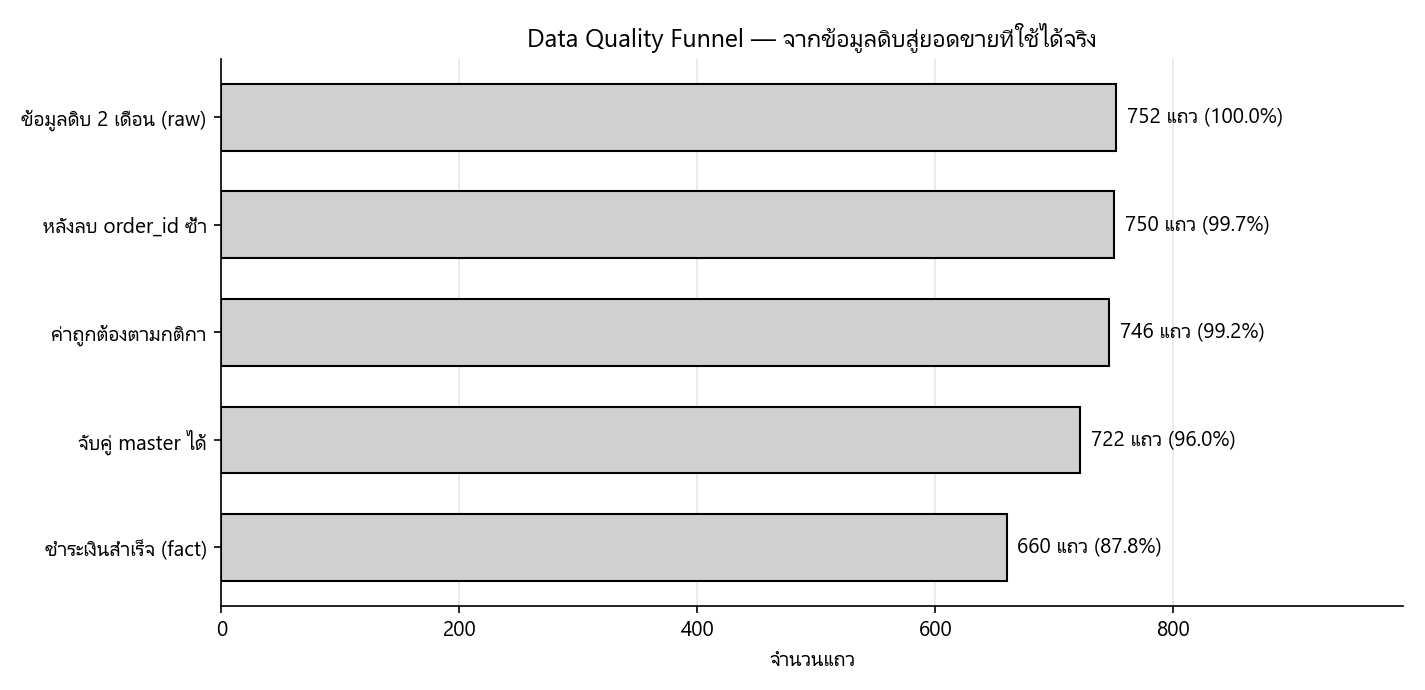

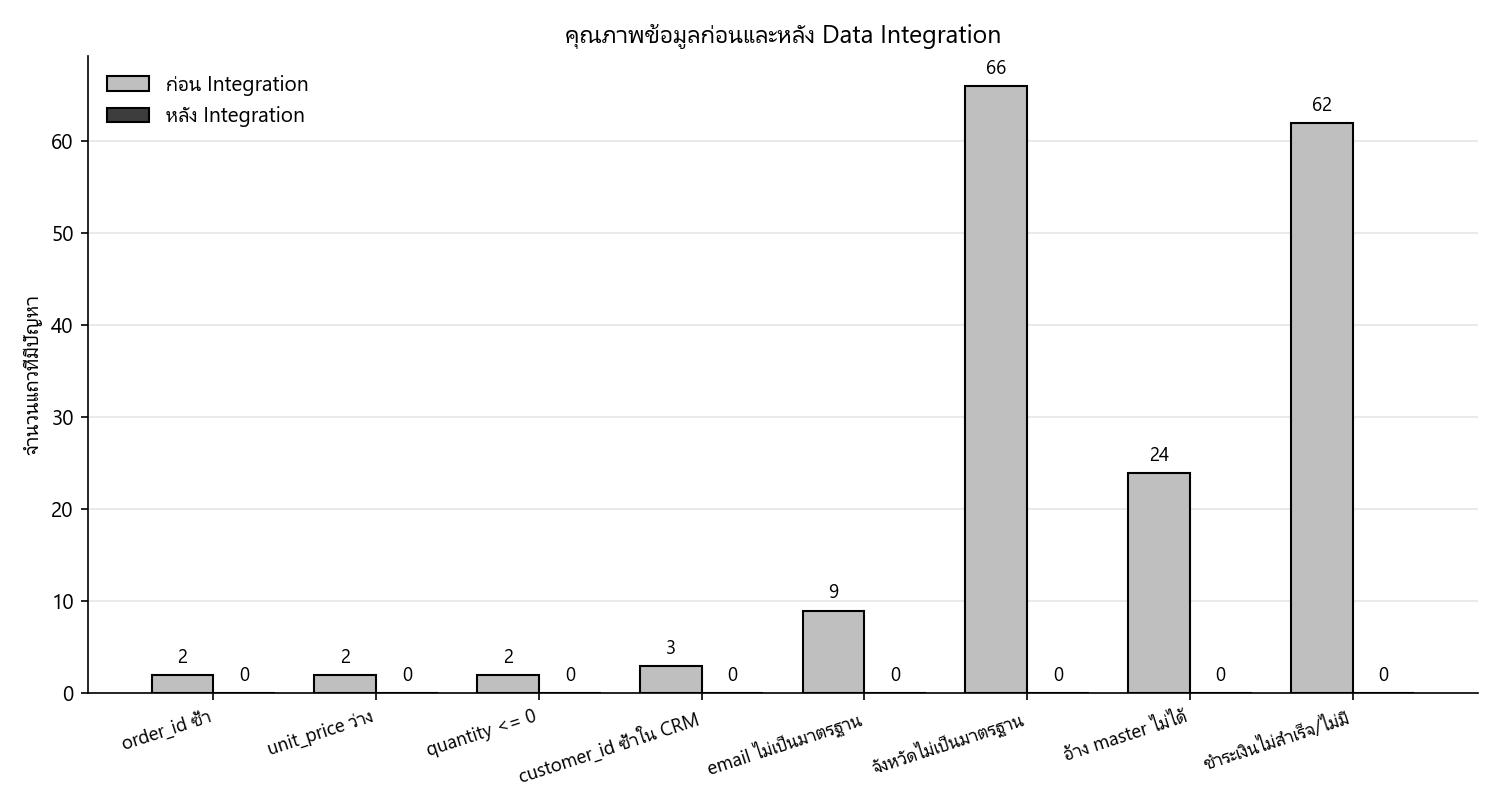

In [24]:
from IPython.display import Image, display

display(Image(filename=str(ip.FIGURES / "dq_funnel.png")))
display(Image(filename=str(ip.FIGURES / "dq_before_after.png")))

---
## 5.6 Analyze — ยอดขายแยกตามจังหวัดและหมวดสินค้า

In [25]:
result["by_province"]

,province,orders,units,net_sales,avg_order_value,share_pct
0,กรุงเทพมหานคร,154,323,2612955.88,16967.25,25.56
1,ขอนแก่น,110,225,2031943.4,18472.21,19.87
2,ระยอง,120,248,1523168.61,12693.07,14.9
3,เชียงใหม่,104,206,1477338.01,14205.17,14.45
4,ภูเก็ต,86,164,1427388.73,16597.54,13.96
5,ชลบุรี,86,171,1151249.46,13386.62,11.26


In [26]:
result["by_category"]

,category,orders,units,net_sales,avg_order_value,share_pct
0,Smartphone,178,384,3092117.34,17371.45,30.24
1,Accessory,180,338,2710582.77,15058.79,26.51
2,Notebook,161,324,2221495.49,13798.11,21.73
3,Smart Home,141,291,2199848.49,15601.76,21.52


In [27]:
summary = result["summary"]
print(f"ยอดขายสุทธิรวม : {summary['net_sales_total']:,.2f} บาท")
print(f"จำนวนธุรกรรม   : {summary['fact_rows']:,} รายการ")
print(f"ยอดขายก่อนหักส่วนลด: {summary['gross_sales_total']:,.2f} บาท")

ยอดขายสุทธิรวม : 10,224,044.09 บาท
จำนวนธุรกรรม   : 660 รายการ
ยอดขายก่อนหักส่วนลด: 10,482,055.70 บาท


---
## คำตอบคำถามวิเคราะห์ 6 ข้อ

ตัวเลขทั้งหมดอ้างอิงจากผลรันจริงในเซลล์ด้านบน

In [28]:
questions = {
    "1. หลังรวมไฟล์ orders มีกี่แถว และเหลือกี่แถวหลังลบ duplicate?": summary["answers"]["q1"],
    "2. มีแถวที่ customer_id หรือ product_id ไม่พบใน Master Data อย่างละกี่แถว?": summary["answers"]["q2"],
    "3. มียอดขายที่ใช้ได้จริงกี่ธุรกรรม และยอดขายสุทธิรวมเท่าใด?": summary["answers"]["q3"],
    "4. จังหวัดใดมียอดขายสุทธิสูงสุด?": summary["answers"]["q4"],
    "5. หมวดสินค้าใดมียอดขายสุทธิสูงสุด?": summary["answers"]["q5"],
    "6. หากสลับลำดับ merge ก่อน cleaning ผลลัพธ์เปลี่ยนอย่างไร?": summary["answers"]["q6"],
}
for question, answer in questions.items():
    print(question)
    print(f"   -> {answer}\n")

1. หลังรวมไฟล์ orders มีกี่แถว และเหลือกี่แถวหลังลบ duplicate?
   -> หลัง concat ได้ 752 แถว และเหลือ 750 แถวหลังลบ order_id ซ้ำ (ลบไป 2 แถว ตามกติกา keep='last')

2. มีแถวที่ customer_id หรือ product_id ไม่พบใน Master Data อย่างละกี่แถว?
   -> customer_id ที่ไม่พบใน CRM มี 22 แถว และ product_id ที่ไม่พบใน product master มี 2 แถว (นับจาก indicator ของ merge บนข้อมูลที่ลบซ้ำแล้ว)

3. มียอดขายที่ใช้ได้จริงกี่ธุรกรรม และยอดขายสุทธิรวมเท่าใด?
   -> ยอดขายที่ใช้ได้จริง 660 ธุรกรรม ยอดขายสุทธิรวม 10,224,044.09 บาท

4. จังหวัดใดมียอดขายสุทธิสูงสุด?
   -> กรุงเทพมหานคร มียอดขายสุทธิสูงสุด 2,612,955.88 บาท (25.56% ของทั้งหมด จาก 154 ธุรกรรม)

5. หมวดสินค้าใดมียอดขายสุทธิสูงสุด?
   -> หมวด Smartphone มียอดขายสุทธิสูงสุด 3,092,117.34 บาท (30.24% จาก 178 ธุรกรรม)

6. หากสลับลำดับ merge ก่อน cleaning ผลลัพธ์เปลี่ยนอย่างไร?
   -> ถ้า merge ก่อน cleaning ผลจะเพี้ยนและเชื่อถือไม่ได้ — CRM มี customer_id ซ้ำ 3 รายการ ทำให้ pd.merge(validate='m:1') โยน MergeError ทันที และถ้าไม่ใส่ validate= แถวคำสั่งซื

### สรุปคุณภาพข้อมูลก่อนและหลัง Data Integration

| ประเด็น | ก่อน | หลัง |
|---|---|---|
| `order_id` ซ้ำ | 2 แถว | 0 |
| `unit_price` ว่าง | 2 แถว | 0 |
| `quantity ≤ 0` | 2 แถว | 0 |
| `customer_id` ซ้ำใน CRM | 3 แถว | 0 |
| email ไม่เป็นมาตรฐาน | 9 แถว | 0 |
| จังหวัดไม่เป็นมาตรฐาน | 66 แถว (14 รูปแบบ) | 0 (6 จังหวัดมาตรฐาน) |
| อ้าง Master Data ไม่ได้ | 24 แถว | 0 |
| ชำระเงินไม่สำเร็จ/ไม่มี | 62 แถว | 0 |

ทุกแถวที่ถูกคัดออกถูกบันทึกไว้ใน `output/rejected_rows.csv` พร้อม `reason_code`
และทุกขั้นตอนถูกบันทึกใน `output/data_quality_report.csv` จึงตรวจสอบย้อนกลับได้ครบ

In [29]:
for path in sorted((ip.OUTPUT).glob("*")) + sorted((ip.FIGURES).glob("*")):
    print(f"{path.parent.name}/{path.name:28s} {path.stat().st_size:>9,} bytes")

output/data_quality_report.csv          9,336 bytes
output/dim_customer.csv                14,847 bytes
output/dim_product.csv                  1,879 bytes
output/fact_sales.csv                  85,777 bytes
output/kpi_summary.json                 5,142 bytes
output/rejected_rows.csv               25,323 bytes
output/summary_by_category.csv            243 bytes
output/summary_by_province.csv            412 bytes
figures/dq_before_after.png             62,552 bytes
figures/dq_funnel.png                   48,527 bytes
